# 2장 2강: 시계열 데이터 모델링과 예측

## 실습 목표

이번 실습에서는 **Bike Sharing Demand** 데이터를 이용하여 시계열 예측의 기본 흐름을 연습합니다.

- 시간 순서를 유지하면서 **Train / Test 데이터**를 분리합니다.
- **AR, I, MA**가 무엇을 의미하는지 확인합니다.
- **ARIMA(2, 1, 1)** 모델을 학습합니다.
- Test 기간의 미래 값을 예측합니다.
- 실제값과 예측값을 비교합니다.
- **MAE, RMSE**를 이용해 예측 성능을 평가합니다.

> 이 실습에서는 2장 2강 교안에 나온 내용만 사용합니다.

## 실습 환경 / 데이터

- Python
- pandas
- matplotlib
- statsmodels
- scikit-learn
- 데이터: `Bike_Sharing_Demand.csv`

### 주요 컬럼

| 컬럼 | 의미 |
|---|---|
| `datetime` | 자전거 대여 기록 시각 |
| `casual` | 비등록 사용자 대여 수 |
| `registered` | 등록 사용자 대여 수 |
| `count` | 전체 자전거 대여 수 |

이번 강에서는 월별 대여량 `count`를 시계열로 사용합니다.

## 실습 준비

다음 순서로 데이터를 준비합니다.

1. 데이터 불러오기
2. `datetime` 자료형 확인
3. 결측치 확인
4. `datetime`을 날짜/시간 자료형으로 변환
5. 시간 순서대로 정렬
6. 월별 대여량 `count` 준비

> 월별 집계 코드는 시계열 모델링을 위한 준비 코드로 제공됩니다.

In [1]:
# 데이터 누수: 예측 시점에는 사용할 수 없는 정보
# -> 시험점수 데이터에 합격 여부 컬럼이 있다면 : 합격 여부는 데이터 누수일 가능성이 있다.

# ARIMA
# 자기회귀 차수 p: 과거 시차의 범위를 정하는 값
# -> 월별 ARIMA(2,0,0)이면 7월을 설명할 때 6월과 5월 매출을 사용하겠다는 의미

# 차분 차수 d: ARIMA에서 차분을 몇 번 적용할지 나타내는 값
# -> d = 0(차분X), d = 1(1차 차분), d = 2(2차 차분)

# 이동 평균 차수 q : 과거 충격의 시차 범위를 정하는 값
# -> 월별 q=2라면 7월을 설명할 때 6월과 5월의 추정 오차를 반영하겠다

# ARIMA : 차분 및 자기회귀 및 이동평균 요소를 결합한 시계열 모델
# -> ARIMA(2,1,1)은 매출을 한번 차분 한뒤 최근 두 변화량과 직전 오차를 활용하여 모델링 하겠다는 뜻 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

bike = pd.read_csv("Bike_Sharing_Demand.csv")

print("데이터 크기:", bike.shape)
display(bike.head())

print("\n[자료형]")
display(bike[["datetime", "count"]].dtypes.to_frame("dtype"))

print("\n[결측치]")
display(bike[["datetime", "count"]].isna().sum().to_frame("missing"))

데이터 크기: (10886, 12)


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1



[자료형]


,dtype
datetime,str
count,int64



[결측치]


,missing
datetime,0
count,0


In [3]:
bike["datetime"] = pd.to_datetime(bike["datetime"])
bike = bike.sort_values("datetime").reset_index(drop=True)

bike["month"] = (
    bike["datetime"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

monthly = (
    bike.groupby("month", as_index=False)["count"]
    .sum()
)

monthly = monthly.set_index("month")

print("월별 데이터 개수:", len(monthly))
display(monthly.head())
display(monthly.tail())

월별 데이터 개수: 24


,count
month,
2011-01-01,23552
2011-02-01,32844
2011-03-01,38735
2011-04-01,50517
2011-05-01,79713


,count
month,
2012-08-01,130220
2012-09-01,133425
2012-10-01,127912
2012-11-01,105551
2012-12-01,98977


---

# 필수 1. 시간 순서를 유지한 Train / Test 분리

## 배경

시계열 데이터에서는 데이터를 무작위로 섞으면 미래 시점의 데이터가 Train에 포함될 수 있습니다.

따라서 **과거 데이터를 Train**, **그 이후 데이터를 Test**로 사용해야 합니다.

이번 실습에서는 월별 대여량의 **마지막 6개월을 Test 데이터**로 사용합니다.

## 문제 1. Train / Test 데이터를 분리하세요.

### 요구사항

1. `monthly`의 마지막 6개 행을 Test 데이터로 사용합니다.
2. 나머지 데이터를 Train 데이터로 사용합니다.
3. Train과 Test의 시작일과 종료일을 출력합니다.
4. Train과 Test를 같은 그래프에 표시합니다.

### 확인 포인트

- 시간 순서를 유지했는가?
- Test 데이터가 Train 데이터보다 뒤의 기간인가?
- 무작위 분리를 사용하지 않았는가?

=== Train / Test 기간 확인 ===
Train 기간: 2011-01 ~ 2012-06 (총 18개월)
Test  기간: 2012-07 ~ 2012-12 (총 6개월)


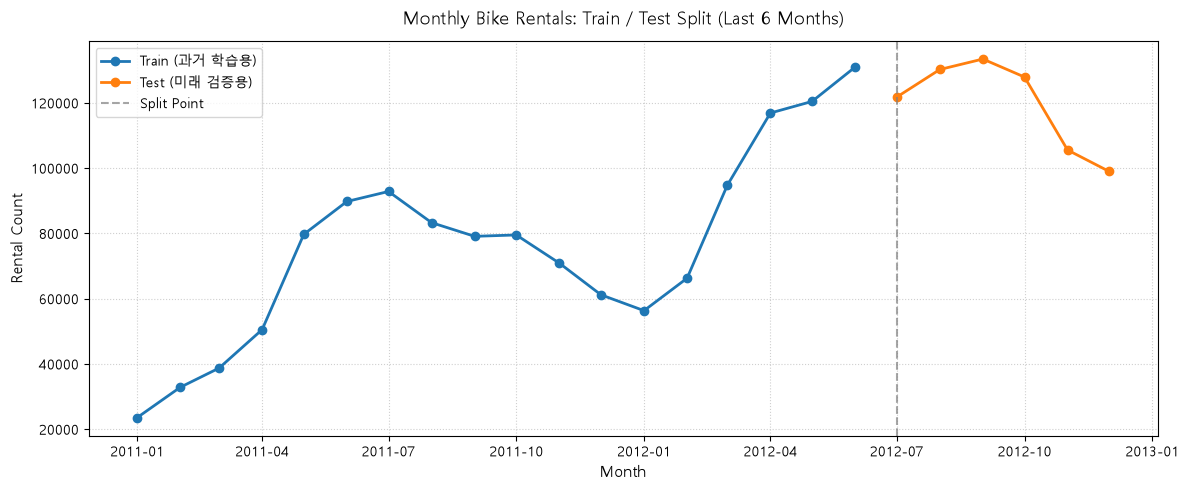

In [4]:
# TODO
# monthly 데이터를 Train / Test로 분리하세요.
import matplotlib.pyplot as plt
plt.rcParams['font.family'] ='Malgun Gothic'
plt.rcParams['axes.unicode_minus'] =False
# 출처: https://giveme-happyending.tistory.com/168 [소연의_개발일지:티스토리]

monthly_df = monthly.copy()
if "month" not in monthly_df.columns:
    monthly_df = monthly_df.reset_index()

monthly_df["month"] = pd.to_datetime(monthly_df["month"])
monthly_df = monthly_df.sort_values('month').reset_index(drop=True)

train = monthly_df.iloc[:-6].copy()
test = monthly_df.iloc[-6:].copy()

print("=== Train / Test 기간 확인 ===")
print(
    f"Train 기간: {train['month'].min().strftime('%Y-%m')} ~ {train['month'].max().strftime('%Y-%m')} (총 {len(train)}개월)"
)
print(
    f"Test  기간: {test['month'].min().strftime('%Y-%m')} ~ {test['month'].max().strftime('%Y-%m')} (총 {len(test)}개월)"
)

plt.figure(figsize=(12, 5))
plt.plot(
    train["month"],
    train["count"],
    marker="o",
    color="tab:blue",
    linewidth=2,
    label="Train (과거 학습용)",
)
plt.plot(
    test["month"],
    test["count"],
    marker="o",
    color="tab:orange",
    linewidth=2,
    label="Test (미래 검증용)",
)

plt.axvline(
    x=test["month"].iloc[0],
    color="gray",
    linestyle="--",
    alpha=0.7,
    label="Split Point",
)
plt.title("Monthly Bike Rentals: Train / Test Split (Last 6 Months)", fontsize=13, pad=12)
plt.xlabel("Month", fontsize=11)
plt.ylabel("Rental Count", fontsize=11)
plt.legend(loc="upper left")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

- 예측 시점은 2012년 6월까지를 알고 있는 상태로 가정
- 2012년 12월 까지의 데이터가 존재하더라도 시계열에서 예측 시점에는 7~12월 데이터를 모르는 것 처럼 남겨둔다.

- 18개월은 18개의 관측값일 뿐, 18개월치의 시간별 표본을 의미하지는 않음
- 해석: 월별 관측 합계(총 기간) 24개월 중 앞선 18개월을 train, 마지막 6개월을 test로 분리 -> 2011년 1월~ 2012년 6월까지의 정보를 토대로 2012년 7~12월까지의 변화를 예측하겠다.
### Q1. 시계열 데이터에서 무작위로 Train / Test를 분리하면 안 되는 이유는 무엇인가요?

**답변:**  
- 시계열 데이터는 시간의 흐름, 순서 자체가 중요한 정보이므로 무작위로 분리하면 누수(look ahead)가 발생한다.
- 또한 모델링의 경우 기존의 관측값을 바탕으로 향후를 예측하는 것이 주 목적이므로, 학습을 시킬 기간과 테스트를 진행할 기간을 반드시 구분해야한다.

---

# 필수 2. ARIMA 모델 학습과 미래 값 예측

## 배경

ARIMA는 다음 세 가지 요소로 구성됩니다.

- **AR(p)**: 과거의 실제 값을 몇 개 사용할 것인가?
- **I(d)**: 차분을 몇 번 적용할 것인가?
- **MA(q)**: 과거의 예측 오차를 몇 개 사용할 것인가?

이번 실습에서는 교안과 동일하게 `ARIMA(2, 1, 1)`을 사용합니다.

## 문제 1. ARIMA(2, 1, 1)의 의미를 설명하세요.

### 요구사항

다음 세 값을 각각 설명합니다.

- `p = 2` 
- `d = 1` 
- `q = 1` 

### Q2. 각각 무엇을 의미하나요?

**답변:**  
- `p = 2` : 최근 2개 행(2개월)의 관측값을 사용하여
- `d = 1` : 1차 차분한다
- `q = 1` : 근데 이제 최근 1개 행(1개월)의 예측 오차를 사용한

## 문제 2. Train 데이터로 ARIMA 모델을 학습하세요.

### 요구사항

1. `statsmodels.tsa.arima.model`에서 `ARIMA`를 불러옵니다.
2. Train 데이터의 `count`를 사용합니다.
3. `order=(2, 1, 1)`을 지정합니다.
4. `fit()`으로 모델을 학습합니다.

### 확인 포인트

- Test 데이터를 학습에 사용하지 않았는가?
- `order=(p, d, q)`의 순서를 알고 있는가?

In [5]:
# TODO
# ARIMA(2, 1, 1) 모델을 생성하고 학습하세요.
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train["count"], order=(2, 1, 1))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  count   No. Observations:                   18
Model:                 ARIMA(2, 1, 1)   Log Likelihood                -180.476
Date:                Wed, 07 Oct 2026   AIC                            368.953
Time:                        18:46:05   BIC                            372.285
Sample:                             0   HQIC                           369.284
                                 - 18                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5770      0.932      0.619      0.536      -1.249       2.403
ar.L2         -0.1038      0.541     -0.192      0.848      -1.165       0.957
ma.L1          0.2235      1.001      0.223      0.8

### 상단 기본 정보
- Dep.Variable -> count : 학습 대상으로 사용한 월별 관측 대여량 합계
- No.Observations -> 18 : 입력한 Train의 관측값 개수
- Model -> ARIMA(2,1,1) : 지정한 p,d,q의 구조
- Sample -> 2011-01 ~ 2012-06 : 학습에 사용한 기간 범위
- Log Likelihood -> -180 : 추정한 모형이 관측자료를 설명하는 '우도'를 로그로 요약한 값 -> "얼마나 그럴만한지"를 수치화 한 값
- AIC / BIC / HQIC -> 368, 372, 369 : 적합도와 모형 복잡도를 함께 고려하는 정도
###
- ar.L1 -> 0.577 : 직전 시점의 차분값에 적용되는 자기회귀 가중치
- ar.L2 -> -0.103 : 두 시점 전 차분값에 적용되는 자기회귀 가중치
- ma.L1 -> 0.223 : 직전 시점의 오차 및 충격에 적용되는 가중치
- sigma2 -> 약 8.347 * 10의 7제곱 : 모형에서 추정한 오차의 분산
###
### ★★★★
- coef -> 추정 계수 : 모형에 들어가는 가중치나 분산 추정값
- std err -> 추정 표준오차 : 계수 추정 불확실성에 관한 값
- z -> 계수, 표준오차에 의한 검정 통계량 : 적절한 추론 조건에서 계수가 0이라는 가설을 판단하는데 사용
- P > |z| : 
- [0.025, 0.975] -> 계수 명목상 95%의 신뢰구간
###

- 표에서 ar.L1을 해석하는 방법: 계수는 0.57, 표준오차는 0.93, z는 0.61, p-value는 0.53, 95% 신뢰구간 -1.2~2.4
- 해석: 추정 계수가 양수인 것으로 확인되지만, 표준오차가 계수보다 큰 경우, 신뢰구간도 음수에서부터 양수로 비교적 넓게 분포되어 있음
- 따라서 직전 변화량의 양의 가중치가 추정되어 있음
- -> 이 데이터 예측하기 어려움

###

- Ljung-Box (L1) / Prob(Q) : Q 약 0.00 / 0.95 -> 표시된 1시차의 잔차 자기상관에 대한 진단
- -> 0.95는 0.05보다 크기 때문에 귀무가설을 기각하지 못함
- -> 귀무가설: 검사한 시차까지 잔차의 자기상관이 없다
###
- Jarque-Bera / Prob(JB) : 0.81 / 0.67 -> 잔차의 정규성에 대한 진단
- -> 0.67은 0.05보다 크기 때문에 귀무가설을 기각하지 못함
- -> 귀무가설: 잔차가 정규분포를 따른다
###
- Heteroskedasticity / Prob(H) : 1.07 -> 오차의 크기가 시간에 따라 달라지는지에 대한 진단
- -> 초반에는 오차가 +-10정도, 후반에는 +-100 정도로 시간이 지남에 따라 오차의 불확실성이 커진다.
###
- Skew : 0.41 -> 오차의 분포가 어느 방향으로 대칭 또는 비대칭을 이루고있는지에 대한 진단
- -> Skew(왜도) : 0에 가까울수록 좌우 대칭모양이다.
- -> 0.41은 양의 대칭을 보이는, 즉 양수방향으로 꼬리가 긴 분포
###
- Kurtosis : 2.30
- -> Kurtosis(첨도) : 3을 기준으로 정규분포에서 얼마나 극단적인 값들이 분포가 되어있는지에 대한 진단
- -> 이 모델링 기준에서는 첨도가 3인데, 3을 기준으로 크거나 작은 극단값들이 얼마나 있는지?

## 문제 3. Test 기간만큼 미래 값을 예측하세요.

### 요구사항

1. `forecast()`를 사용합니다.
2. `steps=len(test)`로 Test 기간과 같은 개수만큼 예측합니다.
3. 예측값의 인덱스를 Test 데이터의 인덱스와 동일하게 설정합니다.
4. `actual`, `predicted` 컬럼을 가진 DataFrame을 만듭니다.
5. 실제값과 예측값을 같은 그래프에 표시합니다.

### 확인 포인트

- Train 마지막 시점 이후의 값을 예측했는가?
- Test 길이와 예측값 개수가 같은가?
- Actual과 Predicted를 구분했는가?

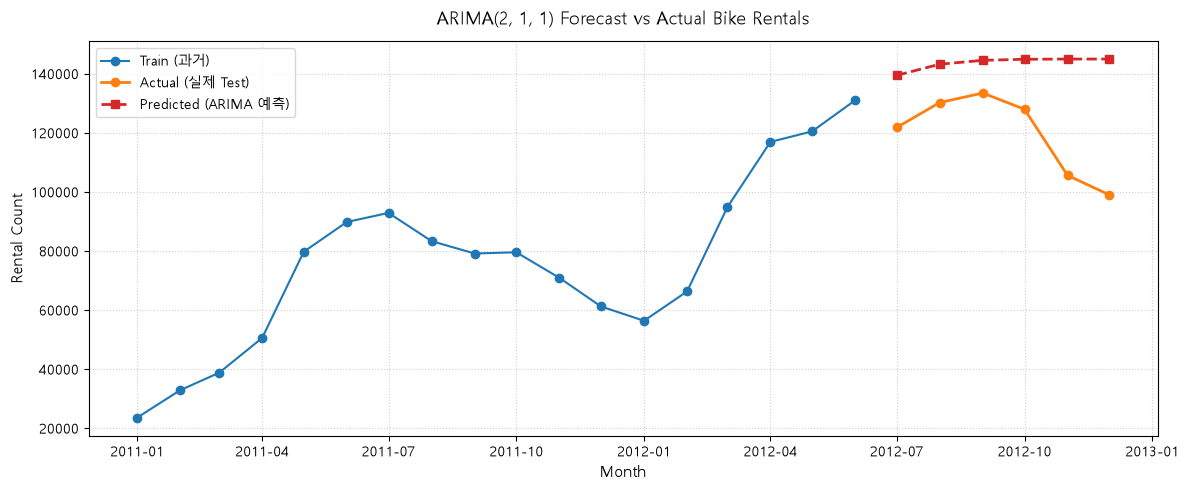

In [6]:
# TODO
# Test 기간만큼 예측하고 Actual / Predicted를 비교하세요.
import matplotlib.pyplot as plt
import pandas as pd

forecats_values = model_fit.forecast(steps=len(test))

forecast_series = pd.Series(forecats_values.values, index=test.index)

comparison_df = pd.DataFrame(
    {"actual": test["count"].values, "predicted": forecast_series.values},
    index=test["month"] if "month" in test.columns else test.index,
)

plt.figure(figsize=(12, 5))

# 전체 흐름 파악을 위해 Train도 함께 표시
x_train = train["month"] if "month" in train.columns else train.index
x_test = test["month"] if "month" in test.columns else test.index

plt.plot(
    x_train, train["count"], marker="o", color="tab:blue", label="Train (과거)"
)
plt.plot(
    x_test,
    test["count"],
    marker="o",
    color="tab:orange",
    linewidth=2,
    label="Actual (실제 Test)",
)
plt.plot(
    x_test,
    forecast_series,
    marker="s",
    color="tab:red",
    linestyle="--",
    linewidth=2,
    label="Predicted (ARIMA 예측)",
)

plt.title(
    "ARIMA(2, 1, 1) Forecast vs Actual Bike Rentals", fontsize=13, pad=12
)
plt.xlabel("Month", fontsize=11)
plt.ylabel("Rental Count", fontsize=11)
plt.legend(loc="upper left")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

- 2012-07: 실제 관측 합계 121,769 / 예측합계 139,405 -> 약 17,636건 과대 예측
- 2012-08: 실제 관측 합계 130,220 / 예측합계 143,188 -> 약 12,969건 과대 예측
- 2012-09: 실제 관측 합계 133,425 / 예측합계 144,494 -> 약 11,069건 과대 예측
- -> 과대예측하는 경향이 보임
###
- 해석: 2011년 1월~ 2012년 6월까지 18개월을 학습하여 향후 6개월을 예측했다.
- 예측값은 모든 Test 월에서 실제보다 높게 측정되었으며 오차가 큰 편이었다.
- 정확하게 해석하기 위해서 추가적인 성능평가도 함께 확인해야한다.


### Q3. `steps=len(test)`는 무엇을 의미하나요?

**답변:**  
- 예측 시점을 기준으로 미래 몇 개월치를 예측할 것인가를 지정한다. (Test 데이터와 동일한 개수의 미래 시점을 예측하겠다.)

### Q4. Actual과 Predicted는 각각 무엇을 의미하나요?

**답변:**  
- Actual은 Test 기간에 실제로 관측된값이며 Predicted는 Train 데이터만 학습한 ARIMA모델이 주어진 Test 기간에 대해 예측한 값이다.

---

# 과제 1. 정상성 진단을 반영한 ARIMA 예측과 예측 신뢰도 평가

## 배경

필수 1의 Train/Test 분리는 유지합니다. 과제에서는 Train 데이터의 정상성을 먼저 진단한 뒤 ARIMA의 차분 차수 d를 선택하여 모델을 다시 학습합니다. MAE·RMSE와 함께 **95% 예측 구간의 하한·상한**을 실제값과 비교합니다.

## 요구사항

1. 필수 1에서 만든 `train`, `test`를 사용합니다. 정상성 진단과 모델 설정에는 Train만 사용합니다.
2. Train의 `count`와 최근 3개 관측값의 이동평균을 그래프로 확인합니다. 원본에 ADF Test를 수행하고 검정통계량과 p-value를 출력합니다. 짧은 월별 자료이므로 이번 과제의 검정 설정은 `maxlag=1, regression="c", autolag="AIC"`로 통일합니다.
3. 유의수준 0.05에서 원본의 단위근 귀무가설을 기각하면 d=0을 우선 검토합니다. 기각하지 못하면 1차 차분한 Train에 같은 설정으로 ADF Test를 다시 수행하고 차분 그래프를 확인합니다. 차분 후 기각하면 d=1을 선택합니다. 차분 후에도 기각하지 못하면 추가 진단이 필요함을 명시하고, 이번 과제에서는 d=1을 잠정 설정하여 예측 과정과 한계를 함께 평가합니다. 선택 근거에 그래프 해석도 포함합니다.
4. **차분하지 않은 Train의 원본 `count`**를 `ARIMA(order=(2, d, 1))`에 전달해 학습합니다. 차분은 모델 내부에서 처리하므로 차분 데이터에 d=1을 다시 적용하지 않습니다. 필수 2의 모델·결과와 구분하여 과제용 변수를 사용합니다.
5. `get_forecast(steps=len(test))`로 Test 기간의 예측값과 95% 예측 구간을 구합니다. `predicted_mean`과 `conf_int(alpha=0.05)`를 활용합니다.
6. Test 날짜에 맞춰 `actual`, `predicted`, `lower_95`, `upper_95`를 가진 `task_result`를 만들고 출력합니다.
7. 과제 모델의 MAE·RMSE를 계산하고 의미를 설명합니다.
8. 실제값·예측값·95% 예측 구간을 같은 그래프에 표시합니다. 시점별 구간 폭과 실제값의 구간 포함 여부를 표에 추가하고, 구간 밖인 시점을 확인합니다.
9. 실제값과 구간의 비교 및 구간 폭을 근거로 예측 신뢰도를 해석합니다. 신뢰도가 낮다고 판단한 구간의 가능한 원인 또는 모델의 한계를 한 가지 이상 설명합니다. 구간 밖인 시점이 없더라도 구간 폭과 자료의 한계를 검토합니다.

> Test는 최종 평가에만 사용합니다. Test 결과를 보고 d나 다른 모델 설정을 다시 선택하지 않습니다. 월별 값은 제공된 CSV의 관측값 합계이며, 월 전체 날짜가 없으면 완전한 월간 총수요로 해석하지 않습니다.

### 확인 포인트

- Train만으로 정상성을 진단하고 d 선택 근거를 제시했는가?
- 1차 차분 후에도 귀무가설을 기각하지 못한 경우 잠정 모델의 한계를 밝혔는가?
- 원본 Train을 모델에 입력하여 이중 차분을 피했는가?
- MAE·RMSE와 실제값·예측값·예측 구간을 함께 확인했는가?
- 구간 밖 실제값과 구간 폭을 근거로 예측 신뢰도와 한계를 설명했는가?
- Q5~Q9에 모두 답했는가?


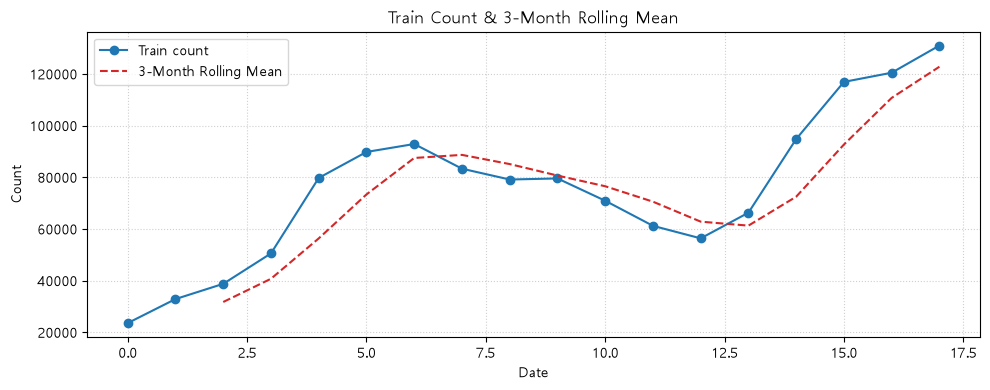

=== Train 원본 ADF Test 결과 ===
ADF Statistic : -1.5711
p-value       : 0.4981

=== Train 1차 차분 ADF Test 결과 ===
ADF Statistic : -1.9814
p-value       : 0.2948


C:\Users\power\AppData\Local\Temp\ipykernel_47864\2487492403.py:29: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_train_orig = adfuller(train_count.dropna(), maxlag=1, regression="c", autolag="AIC")
C:\Users\power\AppData\Local\Temp\ipykernel_47864\2487492403.py:41: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_train_diff = adfuller(train_diff, maxlag=1, regressio

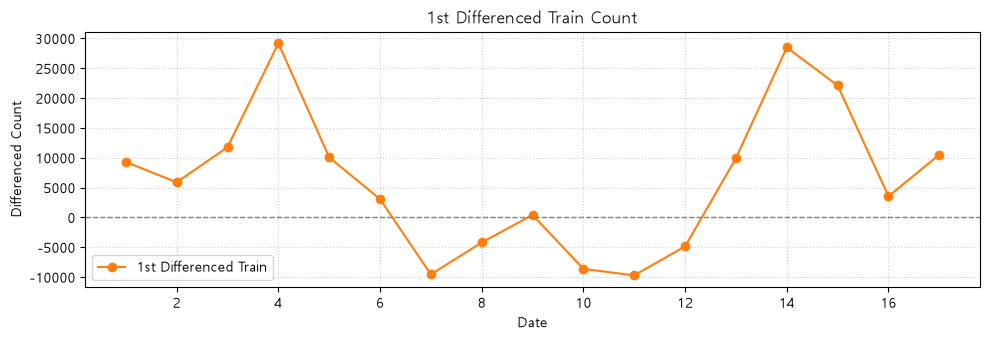


>> 최종 선택된 차분 차수: d = 1

=== Test 기간 모델 평가 지표 ===
MAE  : 23,991.82
RMSE : 27,541.81

=== 예측 결과 및 95% 예측 구간 상세 ===


,actual,predicted,lower_95,upper_95,interval_width,inside_interval
18,"121,769.0","139,405.9","121,498.8","157,313.0","35,814.2",True
19,"130,220.0","143,188.7","106,308.1","180,069.4","73,761.3",True
20,"133,425.0","144,494.5","91,068.7","197,920.3","106,851.6",True
21,"127,912.0","144,855.3","77,592.0","212,118.7","134,526.7",True
22,"105,551.0","144,928.0","65,904.5","223,951.5","158,046.9",True
23,"98,977.0","144,932.5","55,628.1","234,236.8","178,608.7",True


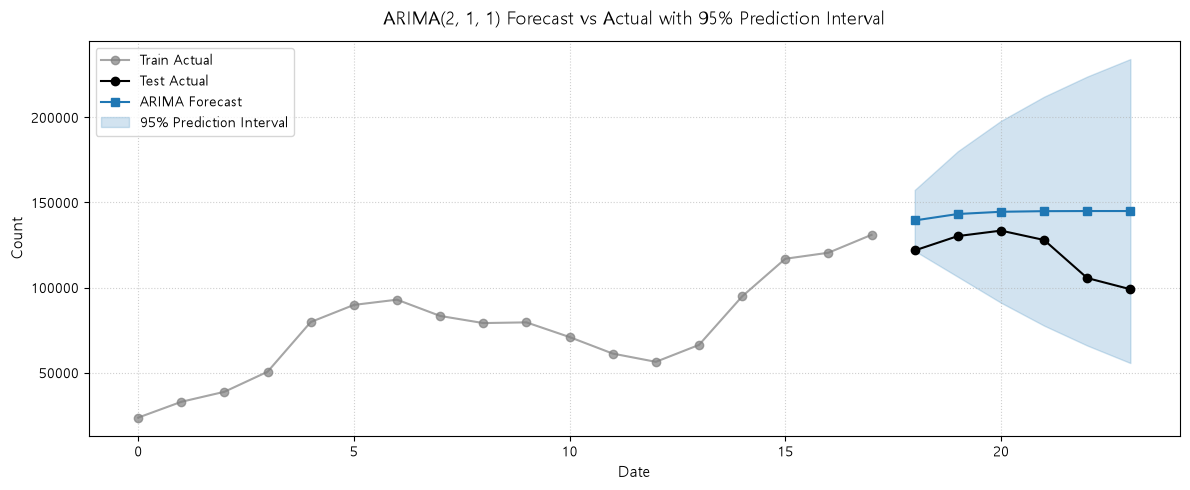

모든 Test 실제값이 95% 예측 구간 내에 위치합니다.


In [8]:
# TODO
# Train 정상성 진단 → d 선택 → 과제용 ARIMA 학습
# → 점예측·95% 예측 구간 → MAE·RMSE → 신뢰도 및 한계 해석
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

# -------------------------------------------------------------
# 1 & 2. Train 데이터 이동평균 시각화 및 원본 ADF Test
# -------------------------------------------------------------
train_count = train["count"].copy()
rolling_mean_3 = train_count.rolling(window=3).mean()

plt.figure(figsize=(10, 4))
plt.plot(train.index, train_count, label="Train count", marker="o", color="tab:blue")
plt.plot(train.index, rolling_mean_3, label="3-Month Rolling Mean", linestyle="--", color="tab:red")
plt.title("Train Count & 3-Month Rolling Mean", fontsize=12)
plt.xlabel("Date")
plt.ylabel("Count")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

# 원본 ADF 검정 설정 통일 (maxlag=1, regression="c", autolag="AIC")
adf_train_orig = adfuller(train_count.dropna(), maxlag=1, regression="c", autolag="AIC")
p_val_orig = adf_train_orig[1]

print("=== Train 원본 ADF Test 결과 ===")
print(f"ADF Statistic : {adf_train_orig[0]:.4f}")
print(f"p-value       : {p_val_orig:.4f}")

# -------------------------------------------------------------
# 3. 1차 차분 수행 및 ADF Test 재실행, 차수 d 결정
# -------------------------------------------------------------
train_diff = train_count.diff().dropna()

adf_train_diff = adfuller(train_diff, maxlag=1, regression="c", autolag="AIC")
p_val_diff = adf_train_diff[1]

print("\n=== Train 1차 차분 ADF Test 결과 ===")
print(f"ADF Statistic : {adf_train_diff[0]:.4f}")
print(f"p-value       : {p_val_diff:.4f}")

# 1차 차분 시각화
plt.figure(figsize=(10, 3.5))
plt.plot(train_diff.index, train_diff, label="1st Differenced Train", marker="o", color="tab:orange")
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.title("1st Differenced Train Count", fontsize=12)
plt.xlabel("Date")
plt.ylabel("Differenced Count")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

# 차수 d 선택 (p_val_orig >= 0.05 이므로 차분 필요. 차분 후 기각 못해도 요구사항에 따라 d=1 잠정 설정)
d = 1
print(f"\n>> 최종 선택된 차분 차수: d = {d}")

# -------------------------------------------------------------
# 4. 과제용 ARIMA(2, d, 1) 모델 학습 (원본 Train 전달)
# -------------------------------------------------------------
task_arima_model = ARIMA(train_count, order=(2, d, 1))
task_arima_fit = task_arima_model.fit()

# -------------------------------------------------------------
# 5 & 6. Test 기간 예측, 95% 예측 구간 추출 및 task_result 구성
# -------------------------------------------------------------
forecast_res = task_arima_fit.get_forecast(steps=len(test))
predicted_mean = forecast_res.predicted_mean
conf_int_95 = forecast_res.conf_int(alpha=0.05)

task_result = pd.DataFrame({
    "actual": test["count"].values,
    "predicted": predicted_mean.values,
    "lower_95": conf_int_95.iloc[:, 0].values,
    "upper_95": conf_int_95.iloc[:, 1].values
}, index=test.index)

# -------------------------------------------------------------
# 7. MAE / RMSE 계산
# -------------------------------------------------------------
task_mae = mean_absolute_error(task_result["actual"], task_result["predicted"])
task_rmse = np.sqrt(mean_squared_error(task_result["actual"], task_result["predicted"]))

print("\n=== Test 기간 모델 평가 지표 ===")
print(f"MAE  : {task_mae:,.2f}")
print(f"RMSE : {task_rmse:,.2f}")

# -------------------------------------------------------------
# 8. 구간 폭 계산 및 포함 여부 확인, 표 및 그래프 시각화
# -------------------------------------------------------------
task_result["interval_width"] = task_result["upper_95"] - task_result["lower_95"]
task_result["inside_interval"] = (task_result["actual"] >= task_result["lower_95"]) & \
                                 (task_result["actual"] <= task_result["upper_95"])

print("\n=== 예측 결과 및 95% 예측 구간 상세 ===")
display(task_result.style.format({
    "actual": "{:,.1f}",
    "predicted": "{:,.1f}",
    "lower_95": "{:,.1f}",
    "upper_95": "{:,.1f}",
    "interval_width": "{:,.1f}"
}))

# 시각화 (실제값, 예측값, 95% 신뢰구간)
plt.figure(figsize=(12, 5))
plt.plot(train.index, train["count"], label="Train Actual", color="gray", marker="o", alpha=0.7)
plt.plot(test.index, task_result["actual"], label="Test Actual", color="black", marker="o")
plt.plot(test.index, task_result["predicted"], label="ARIMA Forecast", color="tab:blue", marker="s")
plt.fill_between(
    test.index,
    task_result["lower_95"],
    task_result["upper_95"],
    color="tab:blue",
    alpha=0.2,
    label="95% Prediction Interval"
)
plt.title(f"ARIMA(2, {d}, 1) Forecast vs Actual with 95% Prediction Interval", fontsize=13, pad=12)
plt.xlabel("Date", fontsize=11)
plt.ylabel("Count", fontsize=11)
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

# 구간 밖 시점 확인
outside_pts = task_result[~task_result["inside_interval"]]
if len(outside_pts) > 0:
    print(f"95% 예측 구간을 벗어난 시점: {list(outside_pts.index.strftime('%Y-%m'))}")
else:
    print("모든 Test 실제값이 95% 예측 구간 내에 위치합니다.")


### Q5. MAE는 어떻게 해석할 수 있나요?

**답변:** 실제 관측값과 모델의 예측값의 차이의 절댓값을 평균 낸 지표.

### Q6. RMSE가 MAE보다 큰 오차에 더 민감한 이유는 무엇인가요?

**답변:** 오차의 제곱의 평균에 제곱근을 취한 것으로, 제곱 값이므로 큰 오차에 더 민감하게 변화하기 때문이다.

### Q7. Train 데이터의 ADF 검정 결과와 그래프를 근거로 d를 어떻게 선택했나요? 정상성 판단에 남아 있는 한계는 무엇인가요?

**답변:** 원본 데이터 그래프에서 완만한 우상향 추세를 확인했고, p-value 0.49로 0.05보다 커서 비정상 데이터라는 귀무가설을 기각하지 못했다. 따라서 추세를 제거하기 위해 1차 차분을 수행했고, 그 결과 평균이 0 부근인 것을 확인하여 d=1을 선택했다. 그러나 1차 차분 후에도 p-value가 약 0.29로 여전히 정상성을 판단할 수 없다.

### Q8. Test 실제값이 95% 예측 구간 밖에 나타난 시점은 언제이며, 구간 폭은 시점별로 어떻게 달라지나요? 이를 근거로 예측 신뢰도를 설명하세요.

**답변:** 모든 Test 실제값이 95% 예측 구간 안에 있다. 구간 폭은 점차 감소하다가 Date=20 시점을 기준으로 지속적으로 넓어진다. 그러나 실제값이 구간 안에 들어왔다고 해서 예측 신뢰도가 높다고 볼 수는 없다. 시간이 지날수록 예측 오차가 급격하게 커지고있으며 95% 예측 구간 자체가 넓기 떄문이다.

### Q9. 예측 신뢰도가 낮다고 판단한 시점 또는 구간은 어디인가요? 가능한 원인이나 모델의 한계를 한 가지 이상 설명하세요.

**답변:**
Test의 후반부(Date=21, 22, 23 시점). 모델이 계절성을 충분히 학습하지 못하여 겨울철의 대여량 감소를 예측하지 못하고있다.

---

# 실습 마무리

아래 질문에 짧게 답해보세요.

1. 시계열 Train/Test 분리에서 가장 중요한 원칙은 무엇인가요?
- 시간 순서를 유지한다는 원칙

2. ARIMA의 `p`, `d`, `q`는 각각 무엇을 의미하나요?
- p는 차분 후 시계열의 과거 값 개수
- d는 차분 횟수
- q는 사용할 과거 예측의 오차의 개수
3. `forecast(steps=6)`은 무엇을 의미하나요?
- Train의 마지막 시점 이후 6개의 미래 시점을 예측
4. Actual과 Predicted의 차이는 무엇인가요?
- 실제 Test값과 모델이 예측한 Predicted 값
5. MAE와 RMSE는 값이 클수록 좋은 지표인가요, 작을수록 좋은 지표인가요?
- 두 지표 모두 작을수록 실제값과 예측값의 차이가 작다.